<a href="https://colab.research.google.com/github/B-DS-Research/B6_Research/blob/main/RMDS_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost lightgbm catboost shap missingno --quiet

#Importing all the required libraries

In [ ]:
import warnings, os, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import shap

from datetime import datetime

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import *
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    ExtraTreesClassifier, ExtraTreesRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)

from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor


# For explanatory good plots

In [ ]:

sns.set_theme(style="whitegrid", font_scale=1.1)

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

for folder in ["figures", "submissions", "outputs", "documentation"]:
    os.makedirs(folder, exist_ok=True)


## Dataset and Key Columns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
TRAIN_PATH = "/content/dataset_A_training.csv"
TEST_PATH = "/content/dataset_A_testing.csv"

## Loading Data

In [ ]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Training shape: (4756, 31)
Testing shape: (4749, 30)


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector
0,4757,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,NaN
1,4758,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,White,Female,NaN,NaN,NaN,NaN,"MSA, Not Principle City",0.0,0.0,NaN
2,4759,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,White,Male,NaN,Married,Own,Not in Labor Force,"MSA, Principle City",1.0,0.0,NaN
3,4760,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,1.0,0.0,agriculture
4,4761,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,Non-MSA,0.0,0.0,wholesale


## Team Logs

In [ ]:
TARGET = "seasonal_vaccine"
ID_COL = "respondent_id"

team_log = {
    "project": "RMDS Hackathon - Seasonal Vaccine Prediction",
    "created_at": str(datetime.now()),
    "target": TARGET,
    "task_type": "Binary Classification",
    "team_members": [
        "Tarun - EDA, modelling, final review",
        "Member 2 - preprocessing",
        "Member 3 - visualisations",
        "Member 4 - baseline models",
        "Member 5 - advanced models",
        "Member 6 - tuning and submissions",
        "Member 7 - XAI and presentation"
    ],
    "workflow": [
        "Data exploration",
        "Missing value analysis",
        "Preprocessing",
        "Model training",
        "Cross-validation",
        "Hyperparameter tuning",
        "Explainable AI",
        "Submission generation"
    ],
    "github_notes": [
        "Commit regularly every 20-30 minutes",
        "Use meaningful commit messages",
        "Upload notebook and outputs to GitHub",
        "Include GitHub and Colab links on first presentation slide"
    ]
}

with open("documentation/teamwork_log.json", "w") as f:
    json.dump(team_log, f, indent=4)

## Basic Data Eploration

In [ ]:
print("Training columns:")
print(train_df.columns.tolist())

print("\nTesting columns:")
print(test_df.columns.tolist())

display(train_df.info())
display(train_df.describe(include="all").T)

overview = {
    "training_rows": int(train_df.shape[0]),
    "training_columns": int(train_df.shape[1]),
    "testing_rows": int(test_df.shape[0]),
    "testing_columns": int(test_df.shape[1]),
    "target": TARGET,
    "id_column": ID_COL
}

with open("outputs/dataset_overview.json", "w") as f:
    json.dump(overview, f, indent=4)

Training columns:
['respondent_id', 'flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'household_adults', 'household_children', 'employment_sector', 'seasonal_vaccine']

Testing columns:
['respondent_id', 'flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', '

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
respondent_id,4756.0,NaN,NaN,NaN,2378.5,1373.08327,1.0,1189.75,2378.5,3567.25,4756.0
flu_concern,4744.0,NaN,NaN,NaN,1.643128,0.91981,0.0,1.0,2.0,2.0,3.0
flu_knowledge,4733.0,NaN,NaN,NaN,1.293049,0.618902,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,4742.0,NaN,NaN,NaN,0.052299,0.222652,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,4724.0,NaN,NaN,NaN,0.734124,0.441846,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,4753.0,NaN,NaN,NaN,0.073848,0.261551,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,4748.0,NaN,NaN,NaN,0.836563,0.369803,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,4747.0,NaN,NaN,NaN,0.365494,0.481619,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,4747.0,NaN,NaN,NaN,0.336634,0.472608,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,4737.0,NaN,NaN,NaN,0.68841,0.463192,0.0,0.0,1.0,1.0,1.0


## Missing Value Analysis

In [ ]:
missing_summary = pd.DataFrame({
    "Missing Count": train_df.isnull().sum(),
    "Missing %": train_df.isnull().mean() * 100
}).sort_values("Missing %", ascending=False)

In [ ]:
display(missing_summary)
missing_summary.to_csv("outputs/missing_summary.csv")

top_missing = missing_summary[missing_summary["Missing %"] > 0].head(20)

,Missing Count,Missing %
employment_sector,2314,48.654331
health_insurance,1925,40.475189
income_poverty,790,16.610597
rent_or_own,381,8.010934
doctor_recc_seasonal,321,6.749369
education,270,5.677040
employment_status,269,5.656013
marital_status,265,5.571909
chronic_med_condition,188,3.952902
child_under_6_months,152,3.195963


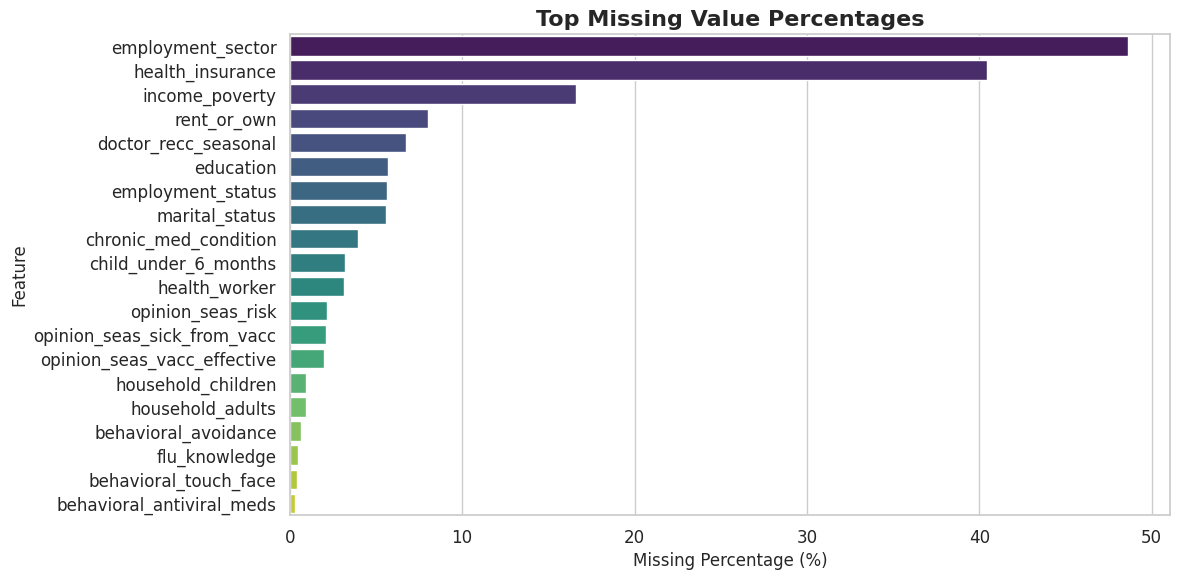

In [ ]:
if len(top_missing) > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_missing["Missing %"], y=top_missing.index, palette="viridis")
    plt.title("Top Missing Value Percentages")
    plt.xlabel("Missing Percentage (%)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig("figures/missing_values_bar.png", dpi=300)
    plt.show()

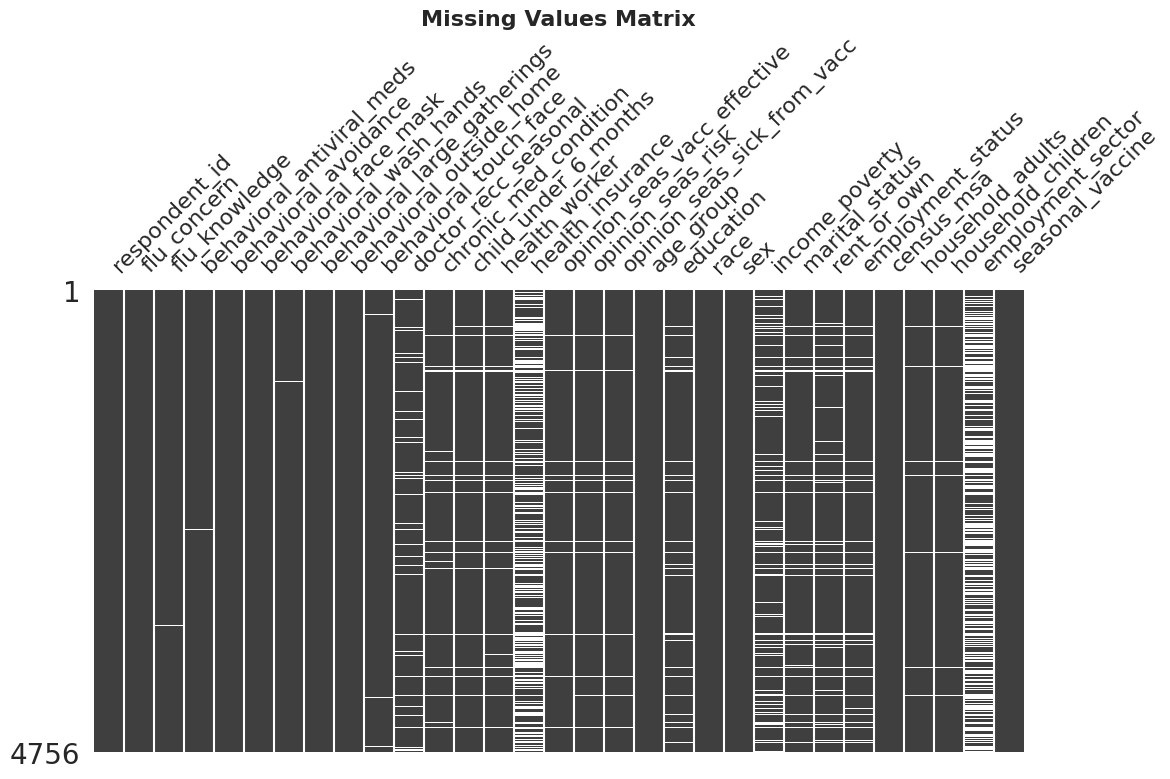

In [ ]:
msno.matrix(train_df, figsize=(12, 6), sparkline=False)
plt.title("Missing Values Matrix", fontsize=16, fontweight="bold")
plt.savefig("figures/missing_matrix.png", dpi=300)
plt.show()

## Target Variable Analysis

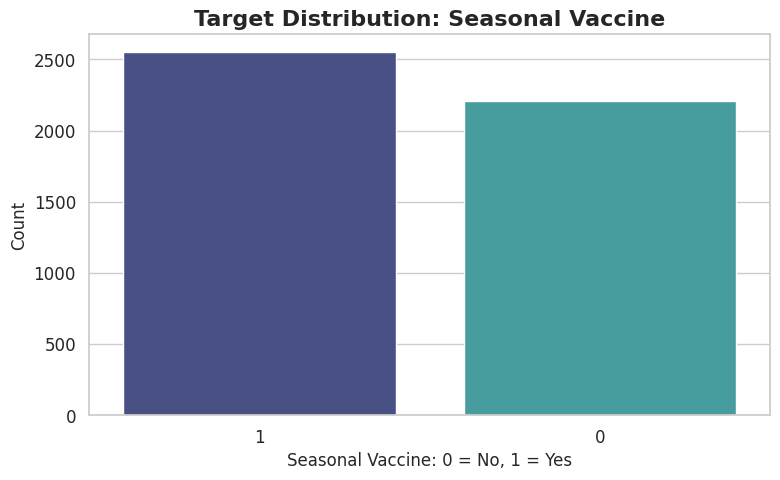

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=train_df,
    x=TARGET,
    order=train_df[TARGET].value_counts().index,
    palette="mako"
)
plt.title("Target Distribution: Seasonal Vaccine")
plt.xlabel("Seasonal Vaccine: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/target_distribution.png", dpi=300)
plt.show()

In [ ]:
class_balance = train_df[TARGET].value_counts(normalize=True) * 100
print("Class balance percentage:")
display(class_balance)
class_balance.to_csv("outputs/class_balance.csv")

Class balance percentage:


,proportion
seasonal_vaccine,
1,53.637511
0,46.362489


# Feature Type Identification

In [ ]:
num_cols = train_df.select_dtypes(include=np.number).columns.tolist()
cat_cols = train_df.select_dtypes(exclude=np.number).columns.tolist()

for col in [TARGET, ID_COL]:
    if col in num_cols:
        num_cols.remove(col)
    if col in cat_cols:
        cat_cols.remove(col)

print("Numerical columns:", len(num_cols))
print(num_cols)

print("Categorical columns:", len(cat_cols))
print(cat_cols)

Numerical columns: 19
['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']
Categorical columns: 10
['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


## Numerical Feature EDA

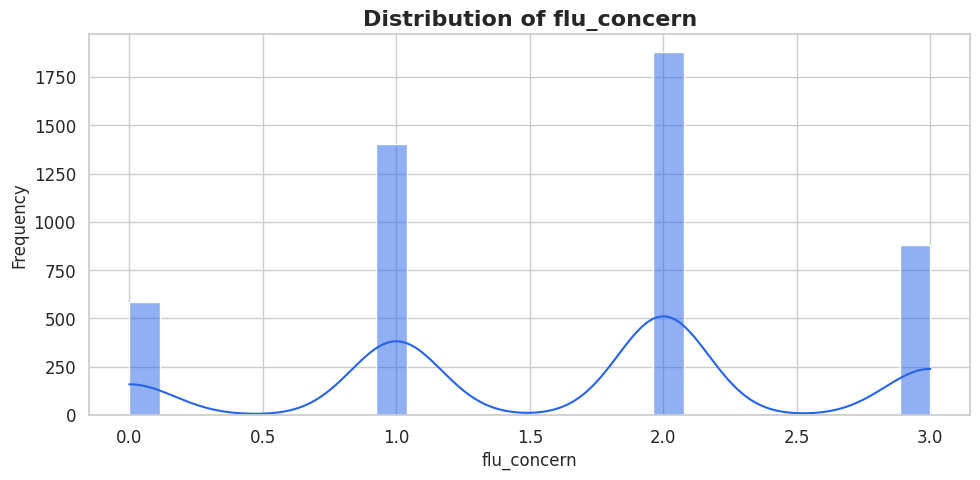

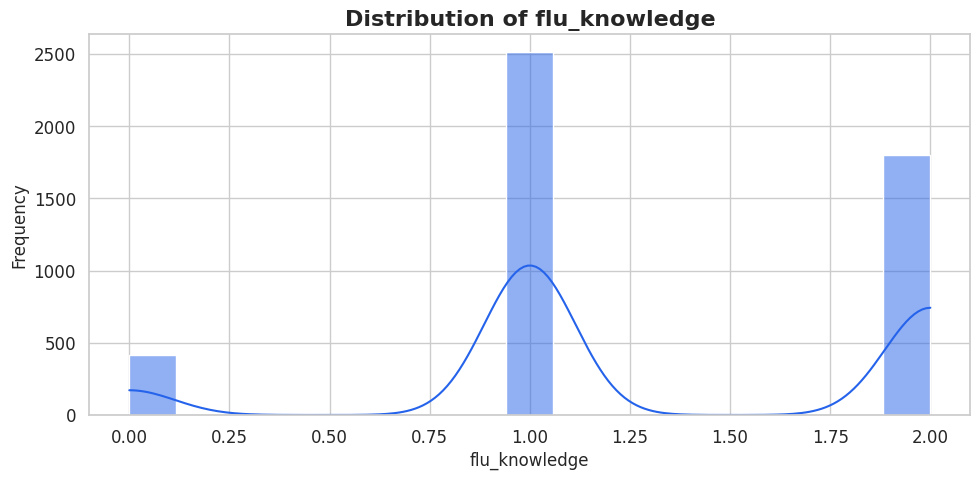

In [ ]:
for col in num_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(train_df[col], kde=True, color="#2563EB")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(f"figures/distribution_{col}.png", dpi=300)
    plt.show()

In [ ]:
for col in num_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=train_df[col], color="#14B8A6")
    plt.title(f"Outlier Analysis: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.savefig(f"figures/boxplot_{col}.png", dpi=300)
    plt.show()

## Categorical Feature EDA

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(12, 5))
    order = train_df[col].value_counts(dropna=False).head(15).index
    sns.countplot(data=train_df, y=col, order=order, palette="rocket")
    plt.title(f"Category Distribution: {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(f"figures/category_{col}.png", dpi=300)
    plt.show()

## Feature Vs Target ariables

In [ ]:
for col in num_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=train_df, x=TARGET, y=col, palette="Set2")
    plt.title(f"{col} by Seasonal Vaccine Status")
    plt.xlabel("Seasonal Vaccine")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(f"figures/target_relation_{col}.png", dpi=300)
    plt.show()

In [ ]:
for col in cat_cols:
    temp = pd.crosstab(train_df[col], train_df[TARGET], normalize="index") * 100
    temp.plot(kind="bar", stacked=True, figsize=(12, 6))
    plt.title(f"{col} vs Seasonal Vaccine")
    plt.xlabel(col)
    plt.ylabel("Percentage")
    plt.legend(title="seasonal_vaccine")
    plt.tight_layout()
    plt.savefig(f"figures/categorical_target_{col}.png", dpi=300)
    plt.show()

## Correlation Analysis

In [ ]:
corr_cols = num_cols + [TARGET]

correlation_matrix = train_df[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=300)
plt.show()

In [ ]:
correlation_matrix.to_csv("outputs/correlation_matrix.csv")

target_corr = correlation_matrix[TARGET].sort_values(ascending=False)
display(target_corr)
target_corr.to_csv("outputs/target_correlations.csv")

## Data leakage check

In [ ]:
possible_leakage = []

for col in train_df.columns:
    if col == TARGET:
        continue

    col_lower = col.lower()
    suspicious_words = ["target", "label", "result", "outcome", "final", "score", "prediction"]

    if any(word in col_lower for word in suspicious_words):
        possible_leakage.append(col)

print("Possible leakage columns to review manually:")
print(possible_leakage)

with open("outputs/possible_leakage_columns.txt", "w") as f:
    f.write(str(possible_leakage))

## Preparing Features and Targets

In [ ]:
X = train_df.drop(columns=[TARGET, ID_COL])
y = train_df[TARGET].astype(int)

test_ids = test_df[ID_COL]
test_features = test_df.drop(columns=[ID_COL])

test_features = test_features.reindex(columns=X.columns, fill_value=np.nan)

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Final numerical features:", len(num_features))
print(num_features)

print("Final categorical features:", len(cat_features))
print(cat_features)

## Preprocessing pipeline

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

## Train Validation splits

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_valid.shape)

## Defining Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=300),
    "Extra Trees": ExtraTreesClassifier(random_state=42, n_estimators=300),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5
    ),
    "LightGBM": LGBMClassifier(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05
    ),
    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=0,
        iterations=300,
        learning_rate=0.05
    )
}

## Model Evaluation Function

In [ ]:
def evaluate_model(name, model):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_valid)
    probs = pipeline.predict_proba(X_valid)[:, 1]

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_valid, preds),
        "Precision": precision_score(y_valid, preds, zero_division=0),
        "Recall": recall_score(y_valid, preds, zero_division=0),
        "F1": f1_score(y_valid, preds, zero_division=0),
        "ROC_AUC": roc_auc_score(y_valid, probs)
    }

    return result, pipeline

## Training and Comparing Models

In [ ]:
results = []
trained_pipelines = {}

for name, model in models.items():
    print(f"Training {name}...")

    try:
        result, pipeline = evaluate_model(name, model)
        results.append(result)
        trained_pipelines[name] = pipeline

    except Exception as error:
        print(f"{name} failed:", error)

results_df = pd.DataFrame(results).sort_values(["ROC_AUC", "F1"], ascending=False)

display(results_df)
results_df.to_csv("outputs/model_results.csv", index=False)

## Model performance Visualisation

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="ROC_AUC", y="Model", palette="viridis")
plt.title("Model Comparison by ROC-AUC")
plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig("figures/model_comparison_roc_auc.png", dpi=300)
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="F1", y="Model", palette="mako")
plt.title("Model Comparison by F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig("figures/model_comparison_f1.png", dpi=300)
plt.show()

## Cross Validation for 5 models

In [ ]:
top_models = results_df["Model"].head(5).tolist()
cv_results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name in top_models:
    model = models[model_name]

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "CV ROC-AUC Mean": scores.mean(),
        "CV ROC-AUC Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV ROC-AUC Mean", ascending=False)

display(cv_results_df)
cv_results_df.to_csv("outputs/cross_validation_results.csv", index=False)

## Best Model Analysis

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]

print("Best validation model:", best_model_name)

valid_preds = best_pipeline.predict(X_valid)
valid_probs = best_pipeline.predict_proba(X_valid)[:, 1]

report = classification_report(y_valid, valid_preds)
print(report)

with open("outputs/classification_report.txt", "w") as f:
    f.write(report)

In [ ]:
cm = confusion_matrix(y_valid, valid_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=300)
plt.show()

fpr, tpr, thresholds = roc_curve(y_valid, valid_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"ROC Curve - {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("figures/roc_curve.png", dpi=300)
plt.show()

## Hyperparameter Tuning - XGBoost

In [ ]:
tuning_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", tuning_model)
])

search = RandomizedSearchCV(
    tuning_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(search.best_params_)

print("Best XGBoost CV ROC-AUC:")
print(search.best_score_)

tuned_model = search.best_estimator_

with open("outputs/tuned_xgboost_params.json", "w") as f:
    json.dump(search.best_params_, f, indent=4)


## TUNED MODEL PERFORMANCE

In [ ]:
tuned_preds = tuned_model.predict(X_valid)
tuned_probs = tuned_model.predict_proba(X_valid)[:, 1]

tuned_result = {
    "Model": "Tuned XGBoost",
    "Accuracy": accuracy_score(y_valid, tuned_preds),
    "Precision": precision_score(y_valid, tuned_preds, zero_division=0),
    "Recall": recall_score(y_valid, tuned_preds, zero_division=0),
    "F1": f1_score(y_valid, tuned_preds, zero_division=0),
    "ROC_AUC": roc_auc_score(y_valid, tuned_probs)
}

display(pd.DataFrame([tuned_result]))
pd.DataFrame([tuned_result]).to_csv("outputs/tuned_model_result.csv", index=False)

## PERMUTATION IMPORTANCE

In [ ]:
perm = permutation_importance(
    best_pipeline,
    X_valid,
    y_valid,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="roc_auc"
)

importance_df = pd.DataFrame({
    "Feature": X_valid.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

display(importance_df.head(20))
importance_df.to_csv("outputs/permutation_importance.csv", index=False)

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(data=importance_df.head(20), x="Importance", y="Feature", palette="mako")
plt.title("Top 20 Feature Importances")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("figures/permutation_importance.png", dpi=300)
plt.show()

## Explainable SHAP AI

In [ ]:
try:
    # Transform validation data using preprocessing pipeline
    X_valid_processed = best_pipeline.named_steps["preprocessor"].transform(X_valid)

    # Get actual transformed feature names
    feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

    # Extract trained model only
    model_only = best_pipeline.named_steps["model"]

    # Create SHAP explainer
    explainer = shap.Explainer(model_only)

    # Calculate SHAP values
    shap_values = explainer(X_valid_processed[:300])

    # Convert processed data into DataFrame with real names
    X_valid_processed_df = pd.DataFrame(
        X_valid_processed[:300],
        columns=feature_names
    )

    # SHAP summary plot with REAL feature names
    shap.summary_plot(
        shap_values,
        X_valid_processed_df,
        max_display=20,
        show=True
    )

except Exception as error:
    print("SHAP failed.")
    print(error)

## CREATING TOP 5 SUBMISSION FILES

In [ ]:
GROUP_NUMBER = "B"

# Select top 5 models from validation performance
top_5_models = results_df.sort_values(
    ["ROC_AUC", "F1"],
    ascending=False
)["Model"].head(5).tolist()

print("Top 5 selected models:")
print(top_5_models)

for rank, model_name in enumerate(top_5_models, start=1):

    # Get trained model pipeline
    model_pipeline = trained_pipelines[model_name]

    # Predict target for testing dataset
    test_predictions = model_pipeline.predict(test_features)

    # Create required submission format
    submission = pd.DataFrame({
        "respondent_id": test_ids,
        "seasonal_vaccine": test_predictions.astype(int)
    })

    # Save CSV in required naming format
    filename = f"submissions/challenge_submission_group_{GROUP_NUMBER}_order_{rank}.csv"
    submission.to_csv(filename, index=False)

    print(f"Saved {filename}")
    display(submission.head())

In [ ]:
!zip -r submissions.zip submissions

updating: submissions/ (stored 0%)
updating: submissions/challenge_submission_group_B_order_5.csv (deflated 68%)
updating: submissions/challenge_submission_group_B_order_1.csv (deflated 68%)
updating: submissions/challenge_submission_group_B_order_3.csv (deflated 68%)
updating: submissions/challenge_submission_group_B_order_2.csv (deflated 68%)
updating: submissions/challenge_submission_group_B_order_4.csv (deflated 68%)
updating: submissions/challenge_submission_group_B_order_tuned_xgboost.csv (deflated 68%)
